In [ ]:
from google.colab import drive as dr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
parent_dr = 'data/'
act_raw= pd.read_csv(parent_dr+'activity_activity.csv',encoding ='cp949')
act_raw.head()

act = act_raw.melt(id_vars=['year', 'month'], var_name='SOURCE', value_name='ton')
coastal_set = {'HR-OK', 'SP-SC', 'SS-DH'}
act['Region'] = act['SOURCE'].apply(lambda x: 'Coastal area' if x in coastal_set else 'Inland area')


The study coverage: 42,287.08 kt
2022 Annual National Total (from activity data): 42,287.08 kt
Coverage compared to NIR 2022: 98.3%
--- 2022 NIR (43011 kt) ---
Coastal Area: 49.7%
Inland Area:  48.6%
Total Analyzed Coverage: 98.3%


# [1] historical emission 2016 ~ 2023

In [ ]:
ef = 0.5295; ckkd = 1.02
ef_2030= 0.5138 #2% linear transition
ef_2050= 0.4352 #12% liner transition

act['emission'] = act['ton'] * ef * ckkd #tonCO2
act['kt'] = act['emission']/1e3
act['mt'] = act['emission']/1e6
act.head()
code_mapping = {'SP-SC': 'C2', 'SS-DH': 'C1', 'HR-OK': 'C3','SS-DY': 'L1', 'HL-DY': 'L2', 'HH-SG': 'L3','AS-JC':'L4','SS-YW':'L5','HH-YW':'L6'}
act['code'] = act['SOURCE'].map(code_mapping)
act['date'] = pd.to_datetime(act[['year', 'month']].assign(day=1))
act.tail()
act.columns

Index(['year', 'month', 'SOURCE', 'ton', 'Region', 'emission', 'kt', 'mt',
       'code', 'date'],
      dtype='object')

CSV 저장 완료 ✅


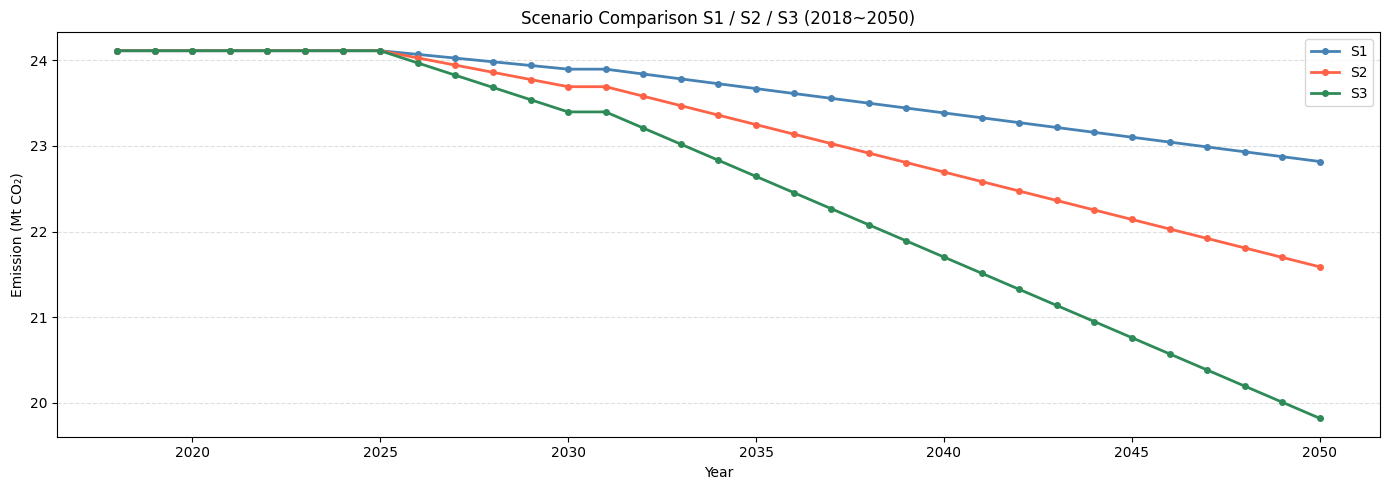

In [ ]:
# ══════════════════════════════════════════
# 1) prepare data
# ══════════════════════════════════════════
base_ton = (act[act['year'] == 2018].groupby(['Region', 'month'])['ton'].sum())

years          = range(2018, 2051)
regions        = act['Region'].dropna().unique()
months         = range(1, 13)
coastal_months = {1, 3, 4, 5, 9, 10, 11}

# ══════════════════════════════════════════
# 2) emission factors
# ══════════════════════════════════════════
def get_ef_s1(year):
    if year < 2025:
        return ef
    elif 2025 <= year <= 2030:
        t = (year - 2025) / (2030 - 2025)
        return ef + t * (ef_2030 - ef)
    elif 2031 <= year <= 2050:
        t = (year - 2031) / (2050 - 2031)
        return ef_2030 + t * (ef_2050 - ef_2030)
    else:
        return ef_2050

# ══════════════════════════════════════════
# 3) Scenario
# ══════════════════════════════════════════
def build_scenario(target_regions, target_months=None, scenario_name='S'):
    """
    target_regions : set, select emission factor you applied, select region you applied
    target_months  : set or None (apply all if you set 'None')
    """
    rows = []
    for year in years:
        ef_s1 = get_ef_s1(year)
        for month in months:
            for region in regions:
                ton = base_ton.get((region, month), np.nan)

                month_cond = (target_months is None) or (month in target_months)

                if region in target_regions and month_cond and year >= 2025:
                    ef_used = ef_s1
                else:
                    ef_used = ef

                emission = ton * ef_used * ckkd

                rows.append({
                    'year'    : year,
                    'month'   : month,
                    'region'  : region,
                    'ton'     : ton,
                    'ef_used' : round(ef_used, 6),
                    'emission': emission,
                    'kt'      : emission / 1e3,
                    'mt'      : emission / 1e6,
                    'date'    : pd.Timestamp(year=year, month=month, day=1),
                    'scenario': scenario_name,})

    df = pd.DataFrame(rows)
    annual = df.groupby('year')[['emission','kt','mt']].sum().reset_index()
    annual['scenario'] = scenario_name
    return df, annual

# ══════════════════════════════════════════
# 4) Run three scenarios
# ══════════════════════════════════════════
# S1: Coastal area + specific months
scen1, scen1_annual = build_scenario(
    target_regions={'Coastal area'},
    target_months=coastal_months,
    scenario_name='S1')

# S2: Coastal + Inland area + specific months
scen2, scen2_annual = build_scenario(target_regions={'Coastal area', 'Inland area'},
    target_months=coastal_months,scenario_name='S2')

# S3: Coastal + Inland area + all months
scen3, scen3_annual = build_scenario(
    target_regions={'Coastal area', 'Inland area'},
    target_months=None,
    scenario_name='S3')

# ══════════════════════════════════════════
# 5) concat & save CSV
# ══════════════════════════════════════════
scen_all        = pd.concat([scen1, scen2, scen3], ignore_index=True)
scen_annual_all = pd.concat([scen1_annual, scen2_annual, scen3_annual], ignore_index=True)

scen_all.to_csv(parent_dr + 'scenarios_monthly.csv', index=False, encoding='utf-8-sig')
scen_annual_all.to_csv(parent_dr + 'scenarios_annual.csv', index=False, encoding='utf-8-sig')
print("Complete CSV ✅")

# ══════════════════════════════════════════
# 6) Visualization
# ══════════════════════════════════════════
colors = {'S1': 'steelblue', 'S2': 'tomato', 'S3': 'seagreen'}

fig, ax = plt.subplots(figsize=(14, 5))
for s, grp in scen_annual_all.groupby('scenario'):
    ax.plot(grp['year'], grp['mt'],
            color=colors[s], linewidth=2, marker='o', markersize=4, label=s)

ax.set_xlabel('Year')
ax.set_ylabel('Emission (Mt CO₂)')
ax.set_title('Scenario Comparison S1 / S2 / S3 (2018~2050)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Social value

In [ ]:
cpi_2010_to_2025 = 1.47
price_raw = pd.read_csv(parent_dr+'carbon_price.csv', encoding='cp949')
price_raw.set_index('year', inplace=True)
price = price_raw.loc[2025:2050].copy()
price['carbon_price'] =  (price['US$2010_tCO2'] * cpi_2010_to_2025).interpolate(method='linear')

# yearly to monthly(flat)
price_monthly = price[['carbon_price']].copy()
price_monthly = price_monthly.loc[price_monthly.index.repeat(12)].copy()
price_monthly.index = pd.date_range(start='2025-01-01', end='2050-12-01', freq='MS')
price_monthly.index.name = 'date'

carbon_df = price_monthly.reset_index().copy()
carbon_df['year']  = carbon_df['date'].dt.year
carbon_df['month'] = carbon_df['date'].dt.month

검증 통과 ✅


In [ ]:
# ── 1) Merge carbon price(2025~2050)
scen_all_cost = scen_all[scen_all['year'] >= 2025].merge(carbon_df[['year','month','carbon_price']], on=['year','month'])


# emission cost(USD)
scen_all_cost['emission_cost_usd']  = scen_all_cost['emission'] * scen_all_cost['carbon_price']
scen_all_cost['emission_cost_musd'] = scen_all_cost['emission_cost_usd'] / 1e6


#  ── 2) amount of reduction(2018 기준)
base = (scen_all[(scen_all['scenario'] == 'S1') & (scen_all['year'] == 2018)].groupby(['region', 'month'])['emission'].sum().reset_index().rename(columns={'emission': 'base_emission'}))
reduction = scen_all_cost.merge(base, on=['region','month'])  # carbon_price 이미 있음
reduction['reduction_t']  = reduction['base_emission'] - reduction['emission']
reduction['reduction_kt'] = reduction['reduction_t'] / 1e3


# ── 3) soocial value: reduction vol × carbon price
reduction['social_usd']  = reduction['reduction_t'] * reduction['carbon_price']
reduction['social_musd'] = reduction['social_usd'] / 1e6


# ── 6) final merge and save
final = scen_all_cost.merge(reduction[['scenario','year','month','region','reduction_t','reduction_kt', 'social_usd','social_musd']],on=['scenario','year','month','region'])
print(final.shape)
print(final.columns.tolist())
final.to_csv(parent_dr + 'final_cost.csv', index=False, encoding='cp949')



(1872, 17)
['year', 'month', 'region', 'ton', 'ef_used', 'emission', 'kt', 'mt', 'date', 'scenario', 'carbon_price', 'emission_cost_usd', 'emission_cost_musd', 'reduction_t', 'reduction_kt', 'social_usd', 'social_musd']
